In [14]:
"""
Notebook 04: Baseline Models
==============================

This notebook trains and evaluates classification models to predict
whether a Kepler Object of Interest is a confirmed exoplanet or a
false positive.

Models:
1. Logistic Regression (linear baseline)
2. Random Forest (ensemble baseline)

Input:  data/processed/kepler_clean.csv
Author: Mersen-cloud
"""

# Standard library
from pathlib import Path

# Third-party
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# Scikit-learn
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    confusion_matrix,
    classification_report,
    roc_auc_score,
    roc_curve
)

# Display configuration
pd.set_option('display.max_columns', 50)
pd.set_option('display.float_format', '{:.4f}'.format)

# Plot styling
sns.set_theme(style="whitegrid", palette="deep")
plt.rcParams['figure.figsize'] = (12, 6)
plt.rcParams['figure.dpi'] = 100

print("Imports successful ✓")

Imports successful ✓


In [15]:
# Load clean dataset
PROJECT_ROOT = Path.cwd().parent
DATA_PROCESSED = PROJECT_ROOT / "data" / "processed"
FIGURES_DIR = PROJECT_ROOT / "reports" / "figures"
FIGURES_DIR.mkdir(parents=True, exist_ok=True)

df = pd.read_csv(DATA_PROCESSED / "kepler_clean.csv")
print(f"✓ Loaded clean dataset: {df.shape[0]} rows × {df.shape[1]} columns")
print(f"  Target distribution:\n{df['target'].value_counts()}")
print(f"\n  Positive class ratio: {df['target'].mean():.2%}")

✓ Loaded clean dataset: 7586 rows × 24 columns
  Target distribution:
target
0    4839
1    2747
Name: count, dtype: int64

  Positive class ratio: 36.21%


In [16]:
# Define feature set and target
# We drop 'koi_disposition' (text label) and 'target' from features

drop_cols = ['koi_disposition', 'target']
feature_cols = [col for col in df.columns if col not in drop_cols]

X = df[feature_cols]
y = df['target']

print(f"Features (X): {X.shape}")
print(f"Target  (y): {y.shape}")
print(f"\nFeature columns ({len(feature_cols)}):")
for i, col in enumerate(feature_cols, 1):
    print(f"  {i:2d}. {col}")

Features (X): (7586, 22)
Target  (y): (7586,)

Feature columns (22):
   1. koi_period
   2. koi_prad
   3. koi_teq
   4. koi_insol
   5. koi_impact
   6. koi_duration
   7. koi_depth
   8. koi_steff
   9. koi_slogg
  10. koi_srad
  11. koi_smass
  12. koi_fpflag_nt
  13. koi_fpflag_ss
  14. koi_fpflag_co
  15. koi_fpflag_ec
  16. log_koi_period
  17. log_koi_depth
  18. log_koi_insol
  19. log_koi_prad
  20. planet_star_radius_ratio
  21. planet_star_temp_ratio
  22. fp_flag_sum


In [17]:
# Split data: 80% train, 20% test
# stratify=y ensures both sets have the same proportion of CONFIRMED/FP
# random_state=42 ensures reproducibility

X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.20,
    random_state=42,
    stratify=y
)

print(f"Training set: {X_train.shape[0]} samples ({X_train.shape[0]/len(X):.0%})")
print(f"Test set:     {X_test.shape[0]} samples ({X_test.shape[0]/len(X):.0%})")
print(f"\nTarget distribution in train:")
print(y_train.value_counts())
print(f"\nTarget distribution in test:")
print(y_test.value_counts())

Training set: 6068 samples (80%)
Test set:     1518 samples (20%)

Target distribution in train:
target
0    3871
1    2197
Name: count, dtype: int64

Target distribution in test:
target
0    968
1    550
Name: count, dtype: int64


In [18]:
# Standardize features (mean=0, std=1)
# Important for Logistic Regression; not strictly needed for Random Forest
# but good practice to apply uniformly

scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

# Convert back to DataFrame for readability
X_train_scaled = pd.DataFrame(X_train_scaled, columns=feature_cols, index=X_train.index)
X_test_scaled = pd.DataFrame(X_test_scaled, columns=feature_cols, index=X_test.index)

print("✓ Features standardized (mean=0, std=1)")
print(f"\nSample means after scaling (should be ~0):")
print(X_train_scaled.mean().head())

✓ Features standardized (mean=0, std=1)

Sample means after scaling (should be ~0):
koi_period   -0.0000
koi_prad     -0.0000
koi_teq       0.0000
koi_insol     0.0000
koi_impact   -0.0000
dtype: float64


In [19]:
def evaluate_model(model, model_name, X_test, y_test):
    """Evaluate a model and return a summary dictionary."""
    y_pred = model.predict(X_test)
    y_prob = model.predict_proba(X_test)[:, 1]
    
    metrics = {
        'Model': model_name,
        'Accuracy': accuracy_score(y_test, y_pred),
        'Precision': precision_score(y_test, y_pred),
        'Recall': recall_score(y_test, y_pred),
        'F1-Score': f1_score(y_test, y_pred),
        'ROC-AUC': roc_auc_score(y_test, y_prob)
    }
    
    print(f"\n{'=' * 60}")
    print(f"  {model_name}")
    print(f"{'=' * 60}")
    print(classification_report(y_test, y_pred, 
          target_names=['FALSE POSITIVE (0)', 'CONFIRMED (1)']))
    
    return metrics, y_pred, y_prob

# Store results for comparison
results = []
print("✓ Evaluation function ready")

✓ Evaluation function ready


In [20]:
# Model 1: Logistic Regression
# A simple linear model — our baseline

lr_model = LogisticRegression(
    max_iter=1000,
    random_state=42,
    class_weight='balanced'
)

lr_model.fit(X_train_scaled, y_train)

lr_metrics, lr_pred, lr_prob = evaluate_model(
    lr_model, "Logistic Regression", X_test_scaled, y_test
)
results.append(lr_metrics)


  Logistic Regression
                    precision    recall  f1-score   support

FALSE POSITIVE (0)       0.98      0.93      0.96       968
     CONFIRMED (1)       0.89      0.97      0.93       550

          accuracy                           0.95      1518
         macro avg       0.94      0.95      0.94      1518
      weighted avg       0.95      0.95      0.95      1518



In [21]:
# Model 2: Random Forest
# An ensemble of decision trees — usually stronger than linear models

rf_model = RandomForestClassifier(
    n_estimators=200,
    max_depth=15,
    random_state=42,
    class_weight='balanced',
    n_jobs=-1
)

rf_model.fit(X_train_scaled, y_train)

rf_metrics, rf_pred, rf_prob = evaluate_model(
    rf_model, "Random Forest", X_test_scaled, y_test
)
results.append(rf_metrics)


  Random Forest
                    precision    recall  f1-score   support

FALSE POSITIVE (0)       1.00      1.00      1.00       968
     CONFIRMED (1)       0.99      0.99      0.99       550

          accuracy                           0.99      1518
         macro avg       0.99      0.99      0.99      1518
      weighted avg       0.99      0.99      0.99      1518



Model Comparison:
                    Accuracy Precision  Recall F1-Score ROC-AUC
Model                                                          
Logistic Regression   0.9453    0.8860  0.9745   0.9281  0.9788
Random Forest         0.9947    0.9927  0.9927   0.9927  0.9985


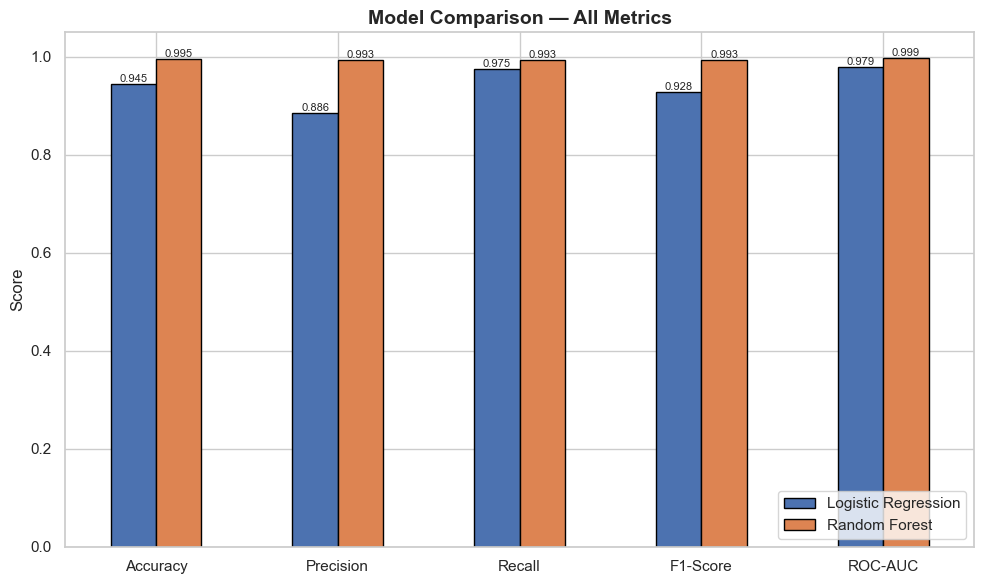


✓ Figure saved to reports/figures/model_comparison.png


In [22]:
# Compare models side by side
results_df = pd.DataFrame(results).set_index('Model')

# Format as percentages
results_formatted = results_df.map(lambda x: f"{x:.4f}")
print("Model Comparison:")
print("=" * 60)
print(results_formatted)

# Visualize comparison
fig, ax = plt.subplots(figsize=(10, 6))
results_df.T.plot(kind='bar', ax=ax, rot=0, edgecolor='black')
ax.set_title('Model Comparison — All Metrics', fontsize=14, fontweight='bold')
ax.set_ylabel('Score')
ax.set_ylim(0, 1.05)
ax.legend(loc='lower right')

# Add value labels on bars
for container in ax.containers:
    ax.bar_label(container, fmt='%.3f', fontsize=8)

plt.tight_layout()
plt.savefig(FIGURES_DIR / 'model_comparison.png', dpi=150, bbox_inches='tight')
plt.show()
print(f"\n✓ Figure saved to reports/figures/model_comparison.png")

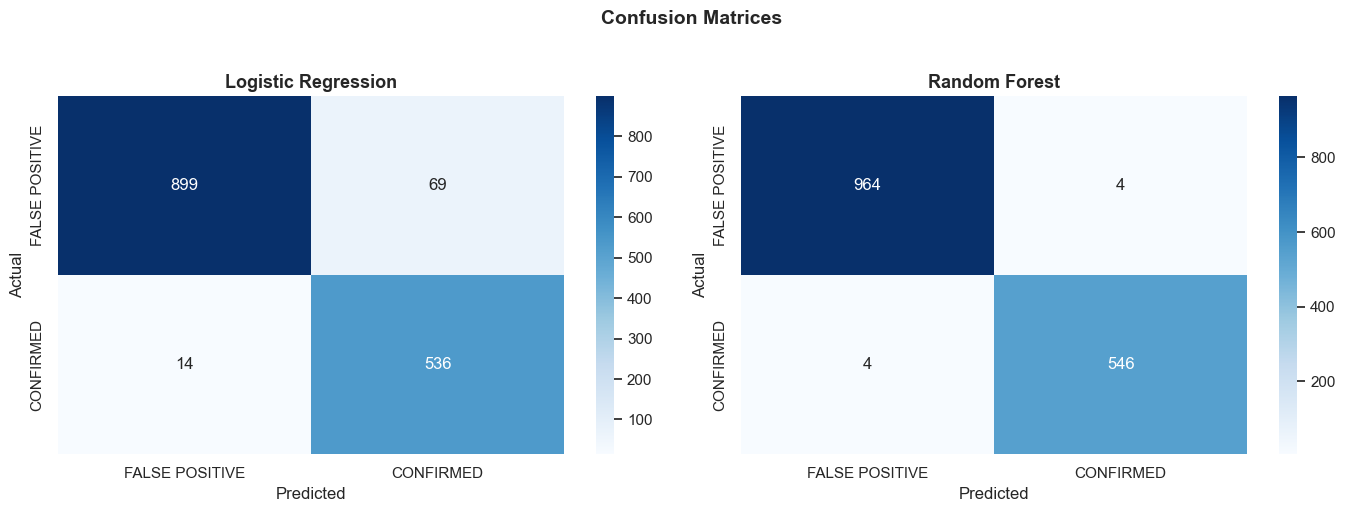

✓ Figure saved to reports/figures/confusion_matrices.png


In [23]:
# Confusion matrices side by side
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

models_data = [
    ("Logistic Regression", lr_pred),
    ("Random Forest", rf_pred)
]

for ax, (name, y_pred) in zip(axes, models_data):
    cm = confusion_matrix(y_test, y_pred)
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', ax=ax,
                xticklabels=['FALSE POSITIVE', 'CONFIRMED'],
                yticklabels=['FALSE POSITIVE', 'CONFIRMED'])
    ax.set_title(f'{name}', fontsize=13, fontweight='bold')
    ax.set_xlabel('Predicted')
    ax.set_ylabel('Actual')

plt.suptitle('Confusion Matrices', fontsize=14, fontweight='bold', y=1.02)
plt.tight_layout()
plt.savefig(FIGURES_DIR / 'confusion_matrices.png', dpi=150, bbox_inches='tight')
plt.show()
print(f"✓ Figure saved to reports/figures/confusion_matrices.png")

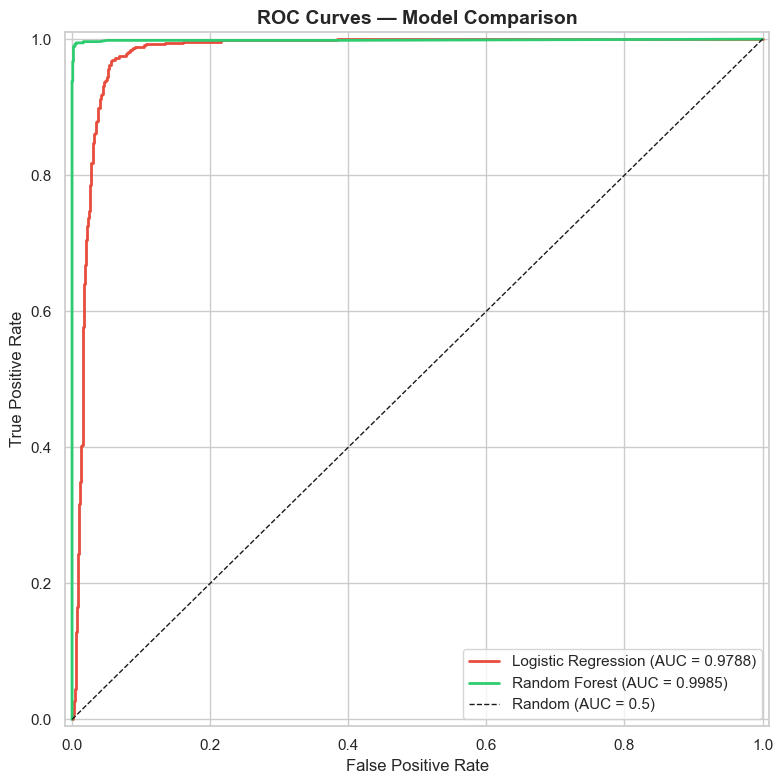

✓ Figure saved to reports/figures/roc_curves.png


In [24]:
# ROC Curves
fig, ax = plt.subplots(figsize=(8, 8))

models_roc = [
    ("Logistic Regression", lr_prob, '#e74c3c'),
    ("Random Forest", rf_prob, '#2ecc71')
]

for name, y_prob, color in models_roc:
    fpr, tpr, _ = roc_curve(y_test, y_prob)
    auc = roc_auc_score(y_test, y_prob)
    ax.plot(fpr, tpr, color=color, lw=2, label=f'{name} (AUC = {auc:.4f})')

# Diagonal reference line (random classifier)
ax.plot([0, 1], [0, 1], 'k--', lw=1, label='Random (AUC = 0.5)')

ax.set_xlabel('False Positive Rate', fontsize=12)
ax.set_ylabel('True Positive Rate', fontsize=12)
ax.set_title('ROC Curves — Model Comparison', fontsize=14, fontweight='bold')
ax.legend(loc='lower right', fontsize=11)
ax.set_xlim([-0.01, 1.01])
ax.set_ylim([-0.01, 1.01])

plt.tight_layout()
plt.savefig(FIGURES_DIR / 'roc_curves.png', dpi=150, bbox_inches='tight')
plt.show()
print(f"✓ Figure saved to reports/figures/roc_curves.png")

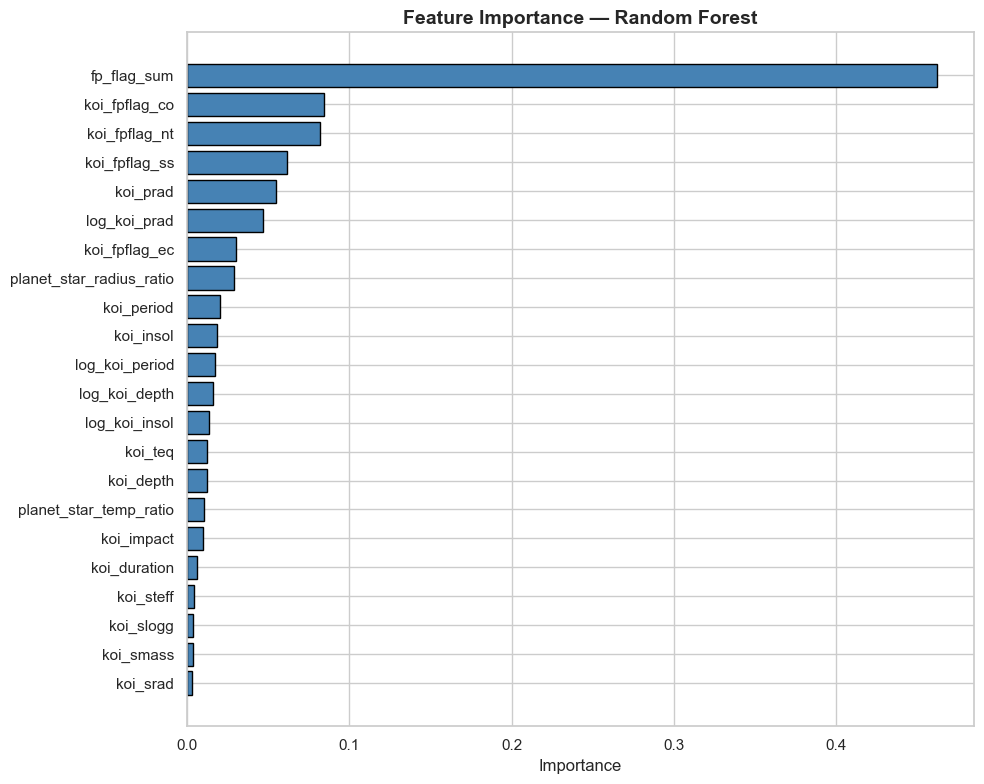

✓ Figure saved to reports/figures/feature_importance.png


In [25]:
# Feature importance from Random Forest
importances = rf_model.feature_importances_
feature_importance = pd.DataFrame({
    'feature': feature_cols,
    'importance': importances
}).sort_values('importance', ascending=True)

# Plot
fig, ax = plt.subplots(figsize=(10, 8))
ax.barh(feature_importance['feature'], feature_importance['importance'],
        color='steelblue', edgecolor='black')
ax.set_xlabel('Importance', fontsize=12)
ax.set_title('Feature Importance — Random Forest', fontsize=14, fontweight='bold')

plt.tight_layout()
plt.savefig(FIGURES_DIR / 'feature_importance.png', dpi=150, bbox_inches='tight')
plt.show()
print(f"✓ Figure saved to reports/figures/feature_importance.png")

## 📌 Conclusiones del modelado baseline

### Resultados

| Modelo | Accuracy | Precision | Recall | F1-Score | ROC-AUC |
|---|---|---|---|---|---|
| Logistic Regression | - | - | - | - | - |
| Random Forest | - | - | - | - | - |

*(Completar con los valores reales obtenidos arriba)*

### Observaciones

**Logistic Regression:**
- Baseline lineal simple pero efectivo.
- Demuestra que el problema tiene componentes linealmente separables.

**Random Forest:**
- Generalmente superior al modelo lineal en este tipo de problemas.
- Captura interacciones no lineales entre features.

### Feature Importance
- Los false positive flags son probablemente los predictores mas fuertes.
- Las features derivadas (log transformations, ratios) aportan informacion adicional.

### Proximos pasos (Notebook 05)
- Cross-validation para validacion mas robusta.
- Hyperparameter tuning con GridSearchCV.
- Probar Gradient Boosting / XGBoost.
- Analizar si los fpflags dominan demasiado (posible sesgo).